# Data_Create Model Data

August 26, 2022, updated January 7, 2025

Caroline Juang, c.juang@columbia.edu

The data is already prepared to some extent. Make sure the other two things are run:
* `Data_CreateENSOIndex.ipynb`: for the SST gradient
* `Ecoprovinces_ClimData.ipynb`: for averaging climate variables by all, forest, nonforest and by ecoregion (not really used for this, was used for other notebooks)
* `Ecoprovinces_ExtendData.ipynb`: for summing MODIS and WUMI by all, forest, nonforest and by ecoregion

Prepare all the data for training the model.
* SST gradient 1982 to present
    * observed
    * detrended (by season)
* WUMI-MODIS burned area data (1984-present)
    * all, forest, nonforest
    * by ecoregion
* climate data (1984-present) (standardized)
    * all, forest, nonforest
    * by ecoregion
 
Additional data (for visualization)
* SST gradient 1981 to present
    * observed
    * detrended (by season)

User inputs: 
* present = should be defined
* seasons = defined
* `climindname` variable = should be defined

In [18]:
# import
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.stats import pearsonr

## User input

In [2]:
# customize seasons for climate variables

# customize number of rolling periods
ant_years = 1 # antecedent years to include (2 antecedent years + current year)
ant_season = 3 # n+1 of months to include in each period (e.g. input 2 would mean 3 months)

firstyear = 1984 # first year of data
finalyear = 2022 # final year of all data (should be same as burned area)
wumiyear = 2020 # final year of wumi data
time_length = int(finalyear-firstyear+1) # get length of timeseries
# translate years into dates (for climate variables)
firsttime = str(firstyear-ant_years)+'-01-01'
finaltime = str(finalyear)+'-12-31'

# importing data string
#directory = 'C:\\Users\\carol\\Documents\\Research Data 2020\\'
directory = '//Users//caroline//Documents//Research Data 2020//'

# for climate variables
#primary_string = '12km\\climate\\primary\\'
primary_string = '12km//climate//primary//'

In [3]:
# create strings of the types of forests, remove #5
province_names = ['1: American Semi-Desert and Desert Province',
                  '2: Arizona-New Mexico Mountains Semi-Desert-Open Woodland-Coniferous Forest-Alpine Meadow Province',
                  '3: Black Hills Coniferous Forest Province',
                  '4: California Coastal Chapparral Forest and Shrub Province',
                  '5: California Coastal Range Open Woodland-Shrub-Coniferous Forest-Meadow Province',
                  '6: California Coastal Steppe-Mixed Forest-Redwood Forest Province',
                  '7: California Dry Steppe Province',
                  '8: Cascade Mixed Forest-Coniferous Forest-Alpine Meadow Province',
                  '9: Chihuahuan Semi-Desert Province',
                  '10: Colorado Plateau Semi-Desert Province',
                  '12: Great Plains-Palouse Dry Steppe Province',
                  '13: Intermountain Semi-Desert Province',
                  '14: Intermountain Semi-Desert and Desert Province',
                  '15: Middle Rocky Mountain Steppe-Coniferous Forest-Alpine Meadow Province',
                  '16: Nevada-Utah Mountains-Semi-Desert-Coniferous Forest-Alpine Meadow Province',
                  '17: Northern Rocky Mountain Forest-Steppe-Coniferous Forest-Alpine Meadow Province',
                  '18: Pacific Lowland Mixed Forest Province',
                  '19: Sierran Steppe-Mixed Forest-Coniferous Forest-Alpine Meadow Province',
                  '20: Southern Rocky Mountain Steppe-Open Woodland-Coniferous Forest-Alpine Meadow Province',
                  '21: Southwest Plateau and Plains Dry Steppe and Shrub Province']
province_num = [item for item in range(len(province_names)+1+1)]
province_num.remove(11) # remove empty ecoregion - no overlap btwn westUS map and ecoregion
dfnames = ['allwestUS', 'ecoprov1', 'ecoprov2', 'ecoprov3', 'ecoprov4', 'ecoprov5', 
           'ecoprov6', 'ecoprov7', 'ecoprov8', 'ecoprov9', 'ecoprov10', 
           'ecoprov12','ecoprov13','ecoprov14','ecoprov15',
           'ecoprov16','ecoprov17','ecoprov18','ecoprov19','ecoprov20','ecoprov21']

## Scripts

In [4]:
# average climate variables, within a selected season

def annual_seasonAvg(data, firstmonth, finalmonth):
    """
    This intakes an array of current ecoregion's climate variable of monthly averages (data), 
    Output: an array of yearly averages of the ecoregion climate variable, in the
    seasons specified (firstmonth, finalmonth).
    Requirements: time = an xarray timeseries of months in datetime format.
    """
    withinyear = (time['time.year']>= years[0]) & (time['time.year'] <= years[-1])
    withinseason = (time['time.month'] >= firstmonth) & (time['time.month'] <= finalmonth)
    thistime = time[withinseason & withinyear] # cut time

    # create pd dataframe based on data, for time resampling
    thisdf = pd.DataFrame({'time': pd.to_datetime(thistime.values), 'clim':data[withinyear & withinseason]}).set_index('time')
    thisdf = thisdf.resample('Y').mean().reset_index()
    return thisdf.clim.values

In [5]:
# average climate variables, within a selected season

def annual_seasonAvgDT(data, firstmonth, finalmonth):
    """
    This intakes an array of current ecoregion's climate variable of monthly averages (data), 
    Output: a normalized array of yearly averages of the ecoregion climate variable, in the
    seasons specified (firstmonth, finalmonth). The data is detrended by removing the slope of
    the original seasonal data.
    Requirements: time = an xarray timeseries of months in datetime format.
    """
    withinyear = (time['time.year']>= years[0]) & (time['time.year'] <= years[-1])
    withinseason = (time['time.month'] >= firstmonth) & (time['time.month'] <= finalmonth)
    thistime = time[withinseason & withinyear] # cut time

    # detrend the data
    tmpdata = data[withinyear & withinseason]
    xnum = np.arange(0,len(thistime))
    reg = linregress(xnum, tmpdata)
    m = reg.slope
    b = reg.intercept
    regpredict = m*xnum + b
    # normalize by subtracting the linear regression
    tmpdatanorm = (tmpdata - regpredict) + b

    # create pd dataframe based on data, for time resampling
    thisdf = pd.DataFrame({'time': pd.to_datetime(thistime.values), 'clim':tmpdatanorm}).set_index('time')
    thisdf = thisdf.resample('Y').mean().reset_index()
    return thisdf.clim.values

In [6]:
# average climate variables, within a selected season

def annual_seasonSum(data, firstmonth, finalmonth):
    """
    This intakes an array of current ecoregion's climate variable of monthly averages (data), 
    Output: an array of yearly averages of the ecoregion climate variable, in the
    seasons specified (firstmonth, finalmonth).
    Requirements: time = an xarray timeseries of months in datetime format.
    """
    withinyear = (time['time.year']>= years[0]) & (time['time.year'] <= years[-1])
    withinseason = (time['time.month'] >= firstmonth) & (time['time.month'] <= finalmonth)
    thistime = time[withinseason & withinyear] # cut time
    
    # create pd dataframe based on data, for time resampling
    thisdf = pd.DataFrame({'time': pd.to_datetime(thistime.values), 'clim':data[withinyear & withinseason]}).set_index('time')
    thisdf = thisdf.resample('Y').sum().reset_index()
    return thisdf.clim.values

In [7]:
# get amount in forest

def in_allregion(variable, thisregion):
    """
    For getting the average values only in this particular region of the western US.
    Requirements: the western US study area.
    Returns one weighted average of the variable for each timestep.
    """
    thisregion = westUS*thisregion # get in the study area
    weightedsum = (variable*thisregion).sum(dim=['X','Y'], skipna=True)
    regionsum = thisregion.sum()
    return  weightedsum / regionsum

def in_forest(variable, thisregion):
    """
    For getting the average values only in a forest area.
    Requirements: the forest netCDF.
    Returns one weighted average of the variable for each timestep.
    """
    forestregion = forest*thisregion # get in the region
    weightedsum = (variable*(forestregion)).sum(dim=['X','Y'], skipna=True)
    forestsum = (forestregion).sum()
    return  weightedsum / forestsum


def in_nonforest(variable, thisregion):
    """
    For getting the average values only in a nonforested area in the western US.
    Requirements: the forest netCDF, a mask of the western US.
    Returns one weighted average of the variable for each timestep and the selected region.
    """
    nonforestregion = nonforest*thisregion # get in the region
    weightedsum = (variable*(nonforestregion)).sum(dim=['X','Y'], skipna=True)
    nonforestsum = (nonforestregion).sum()
    return  weightedsum / nonforestsum

# import data

In [8]:
# import western US study area
#westUS_string = directory + '12km\\study_area\\westUS.nc'
westUS_string = directory + '12km//study_area//westUS.nc'
westUS = xr.open_dataset(westUS_string, engine='netcdf4')
westUS = westUS.westUS

# import forest
#forest_string = directory + '12km\\landcover\\US_ForestType_Ruefenacht\\forest_type_frac.nc'
forest_string = directory + '12km//landcover//US_ForestType_Ruefenacht//forest_type_frac.nc'
forest = xr.open_dataset(forest_string, engine='netcdf4')
forest = forest.forest_type_frac.sum(dim='ftype') # sum over all forest types

# create forest and nonforest area 
forest = westUS*forest
nonforest = westUS*(1-forest)
# add province as dimension to the westUS, to combine with ecoregions
westUS = westUS.expand_dims({'province':[0]})

In [9]:
# Bailey's ecoprovinces
#ecoreg_string = directory + '12km\\landcover\\Ecoregions_EPA\\bailey_ecoprovince.nc'
ecoreg_string = directory + '12km//landcover//Ecoregions_EPA//bailey_ecoprovince.nc'
ecoreg = xr.open_dataset(ecoreg_string, engine='netcdf4')
print(ecoreg.bailey_ecoprovince.province.legend)

# add in entire western US
ecoreg = xr.concat([westUS, ecoreg.bailey_ecoprovince], dim='province')
# remove the ecoregion that does not overlap with the western US
ecoreg = ecoreg.sel(province=province_num)

1: American Semi-Desert and Desert Province, 2: Arizona-New Mexico Mountains Semi-Desert-Open Woodland-Coniferous Forest-Alpine Meadow Province, 3: Black Hills Coniferous Forest Province, 4: California Coastal Chapparral Forest and Shrub Province, 5: California Coastal Range Open Woodland-Shrub-Coniferous Forest-Meadow Province, 6: California Coastal Steppe-Mixed Forest-Redwood Forest Province, 7: California Dry Steppe Province, 8: Cascade Mixed Forest-Coniferous Forest-Alpine Meadow Province, 9: Chihuahuan Semi-Desert Province, 10: Colorado Plateau Semi-Desert Province, 11: Great Plains Steppe Province, 12: Great Plains-Palouse Dry Steppe Province, 13: Intermountain Semi-Desert Province, 14: Intermountain Semi-Desert and Desert Province, 15: Middle Rocky Mountain Steppe-Coniferous Forest-Alpine Meadow Province, 16: Nevada-Utah Mountains-Semi-Desert-Coniferous Forest-Alpine Meadow Province, 17: Northern Rocky Mountain Forest-Steppe-Coniferous Forest-Alpine Meadow Province, 18: Pacific 

# Area Burned

In [10]:
# import fire data, both modis and wumi databases
# all data
wumi = pd.read_csv('west_US_fires_ecoprovinces.txt', header=0, index_col=0)
modis = pd.read_csv('west_US_fires_modis_ecoprovinces.txt', header=0, index_col=0)
# forest
wumifor = pd.read_csv('west_US_fires_ecoprovinces_forest.txt', header=0, index_col=0)
modisfor = pd.read_csv('west_US_fires_modis_ecoprovinces_forest.txt', header=0, index_col=0)
# non-forest
wuminon = pd.read_csv('west_US_fires_ecoprovinces_nonforest.txt', header=0, index_col=0)
modisnon = pd.read_csv('west_US_fires_modis_ecoprovinces_nonforest.txt', header=0, index_col=0)

dropthisreg = '11.0'
# drop NaN ecoregion
wumi.drop(columns=dropthisreg, inplace=True)
wumifor.drop(columns=dropthisreg, inplace=True)
wuminon.drop(columns=dropthisreg, inplace=True)
modis.drop(columns=dropthisreg, inplace=True) 
modisfor.drop(columns=dropthisreg, inplace=True)
modisnon.drop(columns=dropthisreg, inplace=True)

# add column of entire western US burned area as ecoregion 0
wumi.insert(0,'all',wumi.sum(axis=1))
wumifor.insert(0,'all',wumifor.sum(axis=1))
wuminon.insert(0,'all',wuminon.sum(axis=1))
modis.insert(0,'all',modis.sum(axis=1))
modisfor.insert(0,'all',modisfor.sum(axis=1))
modisnon.insert(0,'all',modisnon.sum(axis=1))

# rename columns to proper ecoregions
wumi.columns = province_num
wumifor.columns = province_num
wuminon.columns = province_num
modis.columns = province_num
modisfor.columns = province_num
modisnon.columns = province_num

## regress WUMI with MODIS (user input needed)

In [11]:
# user define the years to predict with modis
provinces = wumi.columns.values
firstyearmodis = modis.index.min()

In [12]:
# go through each ecoprovince and regress (all area)

m = np.zeros(len(provinces))
b = np.zeros(len(provinces))
yearstopredict = np.arange(wumiyear+1, finalyear+1, 1)
predicted = np.zeros((len(yearstopredict), len(provinces)))

i = 0
for thisregion in np.arange(len(provinces)-1):
    # create linear regression of the relationship
    # for a single ecoprovince, convert to numpy array
    tmpMODIS = modis.loc[firstyearmodis:wumiyear].iloc[:,[thisregion]]
    tmpMODIS = tmpMODIS.to_numpy().flatten()
    tmpint = wumi.loc[firstyearmodis:wumiyear].iloc[:,[thisregion]]
    tmpint = tmpint.to_numpy().flatten()
    # if any values are nonzero, replace zeroes with minimum annual value
    if (np.any(tmpint)): # if any values are nonzero
        tmpintmin = np.min(tmpint[tmpint!=0])
        tmpint[tmpint==0] = tmpintmin # replace
        tmpint = np.log10(tmpint) # log
    if (np.any(tmpMODIS)): # if any values are nonzero
        tmpMODISmin = np.min(tmpMODIS[tmpMODIS!=0])
        tmpMODIS[tmpMODIS==0] = tmpMODISmin
        tmpMODIS = np.log10(tmpMODIS)

    # regress
    m[i], b[i] = np.polyfit(tmpMODIS, tmpint, 1)
    # convert MODIS 2019 and 2020 to int (un-log the log fit)
    for j, thispredyear in enumerate(yearstopredict):
        modisvalue = np.log10(modis.iloc[:,[thisregion]].loc[thispredyear].to_numpy().flatten())
        predicted[j, i] = 10**((m[i]*modisvalue) + b[i])
    i+=1
    
# put values back into wumi
for j, thispredyear in enumerate(yearstopredict):
    print('WUMI extended to '+str(thispredyear))
    wumi.loc[thispredyear] = predicted[j,:]
    # make sure total western US (0) is sum of the ecoregions
    wumi.loc[thispredyear][0] = wumi.loc[thispredyear][1:-1].sum()

WUMI extended to 2021
WUMI extended to 2022


/var/folders/bh/cplk6_2163d7cqx4vgqpkzz40000gn/T/ipykernel_92746/3723217281.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted[j, i] = 10**((m[i]*modisvalue) + b[i])
/var/folders/bh/cplk6_2163d7cqx4vgqpkzz40000gn/T/ipykernel_92746/3723217281.py:30: RuntimeWarning: divide by zero encountered in log10
  modisvalue = np.log10(modis.iloc[:,[thisregion]].loc[thispredyear].to_numpy().flatten())
/var/folders/bh/cplk6_2163d7cqx4vgqpkzz40000gn/T/ipykernel_92746/3723217281.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wumi.loc[thispredyear][0] = wumi.loc[thispredyear][1:-1].sum()
/var/folders/bh/cplk6_2163d7cqx4vgqpkzz4

In [13]:
# go through each ecoprovince and regress (only forest)

m = np.zeros(len(provinces))
b = np.zeros(len(provinces))
yearstopredict = np.arange(wumiyear+1, finalyear+1, 1)
predicted = np.zeros((len(yearstopredict), len(provinces)))

i = 0
for thisregion in np.arange(len(provinces)-1):
    # create linear regression of the relationship
    # for a single ecoprovince, convert to numpy array
    tmpMODIS = modisfor.loc[firstyearmodis:wumiyear].iloc[:,[thisregion]]
    tmpMODIS = tmpMODIS.to_numpy().flatten()
    tmpint = wumifor.loc[firstyearmodis:wumiyear].iloc[:,[thisregion]]
    tmpint = tmpint.to_numpy().flatten()
    # if any values are nonzero, replace zeroes with minimum annual value
    if (np.any(tmpint)): # if any values are nonzero
        tmpintmin = np.min(tmpint[tmpint!=0])
        tmpint[tmpint==0] = tmpintmin # replace
        tmpint = np.log10(tmpint) # log
    if (np.any(tmpMODIS)): # if any values are nonzero
        tmpMODISmin = np.min(tmpMODIS[tmpMODIS!=0])
        tmpMODIS[tmpMODIS==0] = tmpMODISmin
        tmpMODIS = np.log10(tmpMODIS)
        
        # regress
        m[i], b[i] = np.polyfit(tmpMODIS, tmpint, 1)
        # convert MODIS 2019 and 2020 to int (un-log the log fit)
        for j, thispredyear in enumerate(yearstopredict):
            modisvalue = np.log10(modisfor.iloc[:,[thisregion]].loc[thispredyear].to_numpy().flatten())
            predicted[j, i] = 10**((m[i]*modisvalue) + b[i])
    i+=1
    
# put values back into wumi
for j, thispredyear in enumerate(yearstopredict):
    print('WUMI extended to '+str(thispredyear))
    wumifor.loc[thispredyear] = predicted[j,:]
    # make sure total western US (0) is sum of the ecoregions
    wumifor.loc[thispredyear][0] = wumifor.loc[thispredyear][1:-1].sum()

WUMI extended to 2021
WUMI extended to 2022


/var/folders/bh/cplk6_2163d7cqx4vgqpkzz40000gn/T/ipykernel_92746/3979309015.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted[j, i] = 10**((m[i]*modisvalue) + b[i])
/var/folders/bh/cplk6_2163d7cqx4vgqpkzz40000gn/T/ipykernel_92746/3979309015.py:30: RuntimeWarning: divide by zero encountered in log10
  modisvalue = np.log10(modisfor.iloc[:,[thisregion]].loc[thispredyear].to_numpy().flatten())
/var/folders/bh/cplk6_2163d7cqx4vgqpkzz40000gn/T/ipykernel_92746/3979309015.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wumifor.loc[thispredyear][0] = wumifor.loc[thispredyear][1:-1].sum()
/var/folders/bh/cplk6_2163d7cqx

In [14]:
# go through each ecoprovince and regress (only nonforest)

m = np.zeros(len(provinces))
b = np.zeros(len(provinces))
yearstopredict = np.arange(wumiyear+1, finalyear+1, 1)
predicted = np.zeros((len(yearstopredict), len(provinces)))

i = 0
for thisregion in np.arange(len(provinces)-1):
    # create linear regression of the relationship
    # for a single ecoprovince, convert to numpy array
    tmpMODIS = modisnon.loc[firstyearmodis:wumiyear].iloc[:,[thisregion]]
    tmpMODIS = tmpMODIS.to_numpy().flatten()
    tmpint = wuminon.loc[firstyearmodis:wumiyear].iloc[:,[thisregion]]
    tmpint = tmpint.to_numpy().flatten()
    # if any values are nonzero, replace zeroes with minimum annual value
    if (np.any(tmpint)): # if any values are nonzero
        tmpintmin = np.min(tmpint[tmpint!=0])
        tmpint[tmpint==0] = tmpintmin # replace
        tmpint = np.log10(tmpint) # log
    if (np.any(tmpMODIS)): # if any values are nonzero
        tmpMODISmin = np.min(tmpMODIS[tmpMODIS!=0])
        tmpMODIS[tmpMODIS==0] = tmpMODISmin
        tmpMODIS = np.log10(tmpMODIS)
    
        # regress
        m[i], b[i] = np.polyfit(tmpMODIS, tmpint, 1)
        # convert MODIS 2019 and 2020 to int (un-log the log fit)
        for j, thispredyear in enumerate(yearstopredict):
            modisvalue = np.log10(modisnon.iloc[:,[thisregion]].loc[thispredyear].to_numpy().flatten())
            predicted[j, i] = 10**((m[i]*modisvalue) + b[i])
    i+=1
    
# put values back into wumi
for j, thispredyear in enumerate(yearstopredict):
    print('WUMI extended to '+str(thispredyear))
    wuminon.loc[thispredyear] = predicted[j,:]
    # make sure total western US (0) is sum of the ecoregions
    wuminon.loc[thispredyear][0] = wuminon.loc[thispredyear][1:-1].sum()

WUMI extended to 2021
WUMI extended to 2022


/var/folders/bh/cplk6_2163d7cqx4vgqpkzz40000gn/T/ipykernel_92746/572512580.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted[j, i] = 10**((m[i]*modisvalue) + b[i])
/var/folders/bh/cplk6_2163d7cqx4vgqpkzz40000gn/T/ipykernel_92746/572512580.py:30: RuntimeWarning: divide by zero encountered in log10
  modisvalue = np.log10(modisnon.iloc[:,[thisregion]].loc[thispredyear].to_numpy().flatten())
/var/folders/bh/cplk6_2163d7cqx4vgqpkzz40000gn/T/ipykernel_92746/572512580.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wuminon.loc[thispredyear][0] = wuminon.loc[thispredyear][1:-1].sum()
/var/folders/bh/cplk6_2163d7cqx4vg

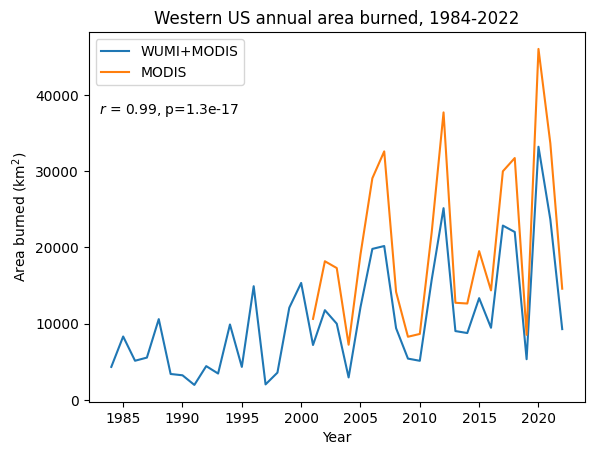

In [30]:
# plot the total western US burned area to check
fig, ax = plt.subplots()
wumi[0].plot(ax=ax)
modis[0].plot(ax=ax)

# calculate pearson correlation at period of overlap
tmpcorr = pearsonr(wumi[0].loc[firstyearmodis:wumiyear],
                   modis[0].loc[firstyearmodis:wumiyear])
# percent change and significance
ax.annotate('$r$ = {:.2f}, p={:.2}'.format(tmpcorr.statistic, tmpcorr.pvalue), 
             (0.02,0.78), c='k', xycoords='axes fraction' )
ax.set_ylabel('Area burned (km$^2$)')
ax.set_xlabel('Year')
ax.set_title('Western US annual area burned, 1984-' + str(finalyear))
ax.legend(['WUMI+MODIS', 'MODIS']);

In [16]:
# export burned area data
filename = 'WUMI-ecoprovinces'
wumi.to_csv(filename +'_all.txt')
wumifor.to_csv(filename + '_for.txt')
wuminon.to_csv(filename + '_non.txt')

In [17]:
# print last time the data was updated
from datetime import datetime

# datetime object containing current date and time
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print("Data last updated =", dt_string)

Data last updated = 09/01/2025 14:43:55


# Climate

## import climate data

In [10]:
# import variables

# precipitation (monthly total, mm)
prec = xr.open_dataset(directory + primary_string + 'prec.nc')
prec = prec.prec.loc[firsttime:finaltime]

# relative humidity (mean, %)
rh = xr.open_dataset(directory + primary_string + 'rh.nc')
rh = rh.rh.loc[firsttime:finaltime]

# solar radiation - downward mean at surface, W/m2
solar = xr.open_dataset(directory + primary_string + 'solar.nc')
solar = solar.solar.loc[firsttime:finaltime]

# max temperature, mean daily
tmax = xr.open_dataset(directory + primary_string + 'tmax.nc')
tmax = tmax.tmax.loc[firsttime:finaltime]

# min temperature
tmin = xr.open_dataset(directory + primary_string + 'tmin.nc')
tmin = tmin.tmin.loc[firsttime:finaltime]

# vapor-pressure deficit, from daily data (mean, hPa)
vpd = xr.open_dataset(directory + primary_string + 'vpd.nc')
vpd = vpd.vpd.loc[firsttime:finaltime]

# number of wet days (fraction of days in the month that had at least 2.54 mm of precipitation, unitless)
wetdays = xr.open_dataset(directory + primary_string + 'wetdays.nc', engine='netcdf4')
wetdays = wetdays.wetdays.loc[firsttime:finaltime]

# wind (mean 2-m wind speed, m/s)
wind = xr.open_dataset(directory + primary_string + 'wind.nc')
wind = wind.wind.loc[firsttime:finaltime]

# create a tmean variable, by averaging tmax and tmin
tmean = (tmax + tmin)/2

In [11]:
# put raw variables in a dictionary
netcdfs = {'prec': prec, 'rh': rh, 'solar': solar, 'tmax': tmax, 
           'tmin': tmin, 'tmean': tmean, 'vpd': vpd,
           'wetdays': wetdays, 'wind': wind}

In [12]:
# create all, forest, nonforest monthly timeseries - storage
climdictmonth = {}
vars = ['precall', 'precfor', 'precnon','rhall','rhfor','rhnon',
        'solarall','solarfor','solarnon','tmaxall','tmaxfor','tmaxnon',
       'tminall','tminfor','tminnon','tmeanall', 'tmeanfor','tmeannon',
        'vpdall','vpdfor','vpdnon',
       'wetdaysall','wetdaysfor','wetdaysnon','windall','windfor','windnon']
for var in vars:
    climdictmonth[var] = np.zeros([len(prec.time), len(ecoreg.province)])

# variable names
varsraw = ['prec', 'rh', 'solar', 'tmax', 'tmin', 'tmean', 'vpd', 'wetdays', 'wind']
varsall = [varname + 'all' for varname in varsraw]
varsfor = [varname + 'for' for varname in varsraw]
varsnon = [varname + 'non' for varname in varsraw]

counter = 0
for thisregion in ecoreg.province:
    print('region '+str(counter+1)+'/'+str(len(province_num)))
    # go through each region and get weighted monthly value for each ecoregion
    for var1, var2 in zip(varsall, varsraw): # populate all
        climdictmonth[var1][:,counter] = in_allregion(netcdfs[var2], ecoreg.sel(province=thisregion)).values.flatten()
    for var1, var2 in zip(varsfor, varsraw): # populate forest
        climdictmonth[var1][:,counter] = in_forest(netcdfs[var2], ecoreg.sel(province=thisregion)).values.flatten()
    for var1, var2 in zip(varsnon, varsraw): # populate nonforest
        climdictmonth[var1][:,counter] = in_nonforest(netcdfs[var2], ecoreg.sel(province=thisregion)).values.flatten()
    counter+=1
    

# after, set variable names - divide into vars that need average 
# vs. vars that need to be summed USER INPUT

# need to be averaged when resampled
varsrawavg = ['rh', 'solar', 'tmax', 'tmin', 'tmean', 'vpd', 'wetdays', 'wind']
varsallavg = [varname + 'all' for varname in varsrawavg]
varsforavg = [varname + 'for' for varname in varsrawavg]
varsnonavg = [varname + 'non' for varname in varsrawavg]
# need to be summed when resampled
varsrawsum = ['prec']
varsallsum = [varname + 'all' for varname in varsrawsum]
varsforsum = [varname + 'for' for varname in varsrawsum]
varsnonsum = [varname + 'non' for varname in varsrawsum]

region 1/21
region 2/21
region 3/21
region 4/21
region 5/21
region 6/21
region 7/21
region 8/21
region 9/21
region 10/21
region 11/21
region 12/21
region 13/21
region 14/21
region 15/21
region 16/21
region 17/21
region 18/21
region 19/21
region 20/21
region 21/21


## Build dataset of full timeseries variable inputs 1983-2022

Exported as `climatefull_ecoprovinces_`...

In [13]:
# get the season and years
time = prec.time # xarray datetime format
ant_rolls = 4 # one season
firstmonth = np.arange(1, (12*ant_years), ant_season)
finalmonth = np.arange(ant_season, (12*ant_years+ant_season), ant_season)
years = np.arange(firstyear-1, finalyear+1)

climbyecoreg = []
climbyecoregfor = []
climbyecoregnon = []

for iregion in np.arange(len(province_num)):# by ecoregion
    print('region ' + str(iregion))
    tmpecoreg = []
    tmpecoregfor = []
    tmpecoregnon = []
    labels = [] # labels only for one ecoregion
    for varraw, varall, varfor, varnon in zip(varsrawavg, varsallavg, varsforavg, varsnonavg): 
        # iterate through each variable
        # seasonal AVERAGEs per ecoregion
        for index in np.arange(len(firstmonth)):
            # calculate the seasonal average
            climavg = annual_seasonAvg(climdictmonth[varall][:,iregion], 
                                       firstmonth[index], finalmonth[index])
            climavgfor = annual_seasonAvg(climdictmonth[varfor][:,iregion], 
                                          firstmonth[index], finalmonth[index])
            climavgnon = annual_seasonAvg(climdictmonth[varnon][:,iregion], 
                                          firstmonth[index], finalmonth[index])
            tmpecoreg.append(climavg)
            tmpecoregfor.append(climavgfor)
            tmpecoregnon.append(climavgnon)
            label = varraw +' y0 mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) # create string description
            labels.append(label)
    for varraw, varall, varfor, varnon in zip(varsrawsum, varsallsum, varsforsum, varsnonsum): 
        # iterate through each variable
        # seasonal SUMs per ecoregion
        for index in np.arange(len(firstmonth)):
            # calculate the seasonal sum
            climavg = annual_seasonSum(climdictmonth[varall][:,iregion], firstmonth[index], finalmonth[index])
            climavgfor = annual_seasonSum(climdictmonth[varfor][:,iregion], firstmonth[index], finalmonth[index])
            climavgnon = annual_seasonSum(climdictmonth[varnon][:,iregion], firstmonth[index], finalmonth[index])
            tmpecoreg.append(climavg)
            tmpecoregfor.append(climavgfor)
            tmpecoregnon.append(climavgnon)
            label = varraw +' y0 mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) # create string description
            labels.append(label)
    # append all the variables to the ecoregion as a single array
    climbyecoreg.append(tmpecoreg)
    climbyecoregfor.append(tmpecoregfor)
    climbyecoregnon.append(tmpecoregnon)

# rearrange for pandas df
climbyecoreg = np.transpose(climbyecoreg)
climbyecoregfor = np.transpose(climbyecoregfor)
climbyecoregnon = np.transpose(climbyecoregnon)

region 0
region 1
region 2
region 3
region 4
region 5
region 6
region 7
region 8
region 9
region 10
region 11
region 12
region 13
region 14
region 15
region 16
region 17
region 18
region 19
region 20


In [14]:
# free up space for memory
del(netcdfs)
del(prec, rh, solar, tmax, tmin, vpd, wetdays, wind)

In [15]:
# create pandas dfs
dfframesall = {}
dfframesfor = {}
dfframesnon = {}
for iecoreg in np.arange(len(province_num)):
    dfframesall[dfnames[iecoreg]] = pd.DataFrame(climbyecoreg[:,:,iecoreg], index=years, columns=labels)
    dfframesfor[dfnames[iecoreg]] = pd.DataFrame(climbyecoregfor[:,:,iecoreg], index=years, columns=labels)
    dfframesnon[dfnames[iecoreg]] = pd.DataFrame(climbyecoregnon[:,:,iecoreg], index=years, columns=labels)

In [16]:
# standardize the variables
# (1/7/2025)
# So, each observed seasonal climate time series should have a 
# mean of zero and a standard deviation of one.

# storage to save mean and std
climallmean = {} # mean
climformean = {}
climnonmean = {}
climallstd = {} # std
climforstd = {}
climnonstd = {}

# get variables
colnamesvars = dfframesfor[dfnames[0]].columns
# standardize each column separately
for thisname in dfnames:
    tmpall = dfframesall[thisname]
    tmpfor = dfframesfor[thisname]
    tmpnon = dfframesnon[thisname]
    
    tmpmean = tmpall.mean()
    tmpstd = tmpall.std()
    climallmean[thisname] = tmpmean # save df mean
    climallstd[thisname] = tmpstd # save df std
    tmpallnorm = (tmpall - tmpmean)/(tmpstd)

    tmpmean = tmpfor.mean()
    tmpstd = tmpfor.std()
    climformean[thisname] = tmpmean
    climforstd[thisname] = tmpstd
    tmpfornorm = (tmpfor - tmpmean)/(tmpstd)

    tmpmean = tmpnon.mean()
    tmpstd = tmpnon.std()
    climnonmean[thisname] = tmpmean
    climnonstd[thisname] = tmpstd
    tmpnonnorm = (tmpnon - tmpmean)/(tmpstd)
    
    # put them back into the pd dataframes
    dfframesall[thisname] = tmpallnorm
    dfframesfor[thisname] = tmpfornorm
    dfframesnon[thisname] = tmpnonnorm

In [17]:
# export the standardized climate data
for thisname in dfnames:
    filename = 'climatefull_ecoprovinces_'
    dfframesall[thisname].to_csv(filename + thisname+'_all.txt')
    dfframesfor[thisname].to_csv(filename + thisname+'_for.txt')
    dfframesnon[thisname].to_csv(filename + thisname+'_non.txt')
    print('Exported for all, for, non - '+filename + thisname)

# export the mean and std data
for thisname in dfnames:
    filename = 'climatefull_ecoprovinces_'
    climallmean[thisname].to_csv(filename + thisname+'_all_mean.txt')
    climformean[thisname].to_csv(filename + thisname+'_for_mean.txt')
    climnonmean[thisname].to_csv(filename + thisname+'_non_mean.txt')
    climallstd[thisname].to_csv(filename + thisname+'_all_std.txt')
    climforstd[thisname].to_csv(filename + thisname+'_for_std.txt')
    climnonstd[thisname].to_csv(filename + thisname+'_non_std.txt')

# print last time the data was updated
from datetime import datetime

# datetime object containing current date and time
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print("Data last updated =", dt_string)

Exported for all, for, non - climatefull_ecoprovinces_allwestUS
Exported for all, for, non - climatefull_ecoprovinces_ecoprov1
Exported for all, for, non - climatefull_ecoprovinces_ecoprov2
Exported for all, for, non - climatefull_ecoprovinces_ecoprov3
Exported for all, for, non - climatefull_ecoprovinces_ecoprov4
Exported for all, for, non - climatefull_ecoprovinces_ecoprov5
Exported for all, for, non - climatefull_ecoprovinces_ecoprov6
Exported for all, for, non - climatefull_ecoprovinces_ecoprov7
Exported for all, for, non - climatefull_ecoprovinces_ecoprov8
Exported for all, for, non - climatefull_ecoprovinces_ecoprov9
Exported for all, for, non - climatefull_ecoprovinces_ecoprov10
Exported for all, for, non - climatefull_ecoprovinces_ecoprov12
Exported for all, for, non - climatefull_ecoprovinces_ecoprov13
Exported for all, for, non - climatefull_ecoprovinces_ecoprov14
Exported for all, for, non - climatefull_ecoprovinces_ecoprov15
Exported for all, for, non - climatefull_ecoprovi

## Build dataset of prior-year/current-year variables

The final array is `climbyecoreg`, `climbyecoregfor`, `climbyecoregnon`.

Exported as `climate_ecoprovinces_`...

Dimensions are (ecoregion, variable, time)

In [18]:
# get years of data to look at
year_rolls = np.arange(-ant_years, 1, 1)

# this is number of seasons (based on user inputs)
ant_rolls = (ant_years+1)*12/ant_season
firstmonth = np.arange(1, (12*ant_years), ant_season)
finalmonth = np.arange(ant_season, (12*ant_years+ant_season), ant_season)

In [19]:
# import the df files exported in the previous part
for thisname in dfnames:
    filename = 'climatefull_ecoprovinces_'
    dfframesall[thisname].to_csv(filename + thisname+'_all.txt')
    dfframesfor[thisname].to_csv(filename + thisname+'_for.txt')
    dfframesnon[thisname].to_csv(filename + thisname+'_non.txt')

In [20]:
# build dataset of variables to regress

climbyecoreg = []
climbyecoregfor = []
climbyecoregnon = []
#climbyecoreg = np.empty((0,(len(years))), int)
#climbyecoregfor= np.empty((0,(len(years))), int)
#climbyecoregnon = np.empty((0,(len(years))), int)


for iregion in np.arange(len(province_num)):# by ecoregion
    print('region ' + str(iregion))
    tmpecoreg = []
    tmpecoregfor = []
    tmpecoregnon = []
    labels = [] # labels only for one ecoregion
    for varraw, varall, varfor, varnon in zip(varsraw, varsall, varsfor, varsnon): # iterate through each variable
    # select time range per ecoregion
        for prev in year_rolls:
            selectyears = np.arange(firstyear+prev, finalyear+prev+1)
            for index in np.arange(len(firstmonth)):  
                # calculate the seasonal average
                labelfull = varraw +' y0'+' mo '+str(firstmonth[index])+'-'+str(finalmonth[index])
                climavg = dfframesall[dfnames[iregion]][labelfull].loc[selectyears].values
                climavgfor = dfframesfor[dfnames[iregion]][labelfull].loc[selectyears].values
                climavgnon = dfframesnon[dfnames[iregion]][labelfull].loc[selectyears].values
                tmpecoreg.append(climavg)
                tmpecoregfor.append(climavgfor)
                tmpecoregnon.append(climavgnon)
                #tmpecoreg = np.vstack([tmpecoreg,climavg])
                #tmpecoregfor = np.vstack([tmpecoregfor, climavgfor])
                #tmpecoregnon = np.vstack([tmpecoregnon, climavgnon])
                label = varraw +' y'+str(prev)+' mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) # create string description
                labels.append(label)
    # append fire area burned to the variables for the ecoregion
    #labels.append('areaburned') # create string description
    #tmpecoreg.append(wumi.iloc[:,0])
    #tmpecoregfor.append(wumifor.iloc[:,0])
    #tmpecoregnon.append(wuminon.iloc[:,0])
    # append all the variables to the ecoregion as a single array
    climbyecoreg.append(tmpecoreg)
    climbyecoregfor.append(tmpecoregfor)
    climbyecoregnon.append(tmpecoregnon)

# rearrange for pandas df
climbyecoreg = np.transpose(climbyecoreg)
climbyecoregfor = np.transpose(climbyecoregfor)
climbyecoregnon = np.transpose(climbyecoregnon)
    
# the final array is climbyecoreg, climbyecoregfor, climbyecoregnon
# dimensions are (time, variable, ecoregion)

region 0
region 1
region 2
region 3
region 4
region 5
region 6
region 7
region 8
region 9
region 10
region 11
region 12
region 13
region 14
region 15
region 16
region 17
region 18
region 19
region 20


In [21]:
# free up space
del(climdictmonth)

In [22]:
# create pandas dfs
dfframesall = {}
dfframesfor = {}
dfframesnon = {}
for iecoreg in np.arange(len(province_num)):
    dfframesall[dfnames[iecoreg]] = pd.DataFrame(climbyecoreg[:,:,iecoreg], index=None, columns=labels)
    dfframesfor[dfnames[iecoreg]] = pd.DataFrame(climbyecoregfor[:,:,iecoreg], index=None, columns=labels)
    dfframesnon[dfnames[iecoreg]] = pd.DataFrame(climbyecoregnon[:,:,iecoreg], index=None, columns=labels)

In [23]:
# export the climate data
for iecoreg in np.arange(len(province_num)):
    filename = 'climate_ecoprovinces_'
    dfframesall[dfnames[iecoreg]].to_csv(filename + dfnames[iecoreg]+'_all.txt')
    dfframesfor[dfnames[iecoreg]].to_csv(filename + dfnames[iecoreg]+'_for.txt')
    dfframesnon[dfnames[iecoreg]].to_csv(filename + dfnames[iecoreg]+'_non.txt')
    print('Exported for all, for, non - '+filename + dfnames[iecoreg])

# print last time the data was updated
from datetime import datetime

# datetime object containing current date and time
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print("Data last updated =", dt_string)

Exported for all, for, non - climate_ecoprovinces_allwestUS
Exported for all, for, non - climate_ecoprovinces_ecoprov1
Exported for all, for, non - climate_ecoprovinces_ecoprov2
Exported for all, for, non - climate_ecoprovinces_ecoprov3
Exported for all, for, non - climate_ecoprovinces_ecoprov4
Exported for all, for, non - climate_ecoprovinces_ecoprov5
Exported for all, for, non - climate_ecoprovinces_ecoprov6
Exported for all, for, non - climate_ecoprovinces_ecoprov7
Exported for all, for, non - climate_ecoprovinces_ecoprov8
Exported for all, for, non - climate_ecoprovinces_ecoprov9
Exported for all, for, non - climate_ecoprovinces_ecoprov10
Exported for all, for, non - climate_ecoprovinces_ecoprov12
Exported for all, for, non - climate_ecoprovinces_ecoprov13
Exported for all, for, non - climate_ecoprovinces_ecoprov14
Exported for all, for, non - climate_ecoprovinces_ecoprov15
Exported for all, for, non - climate_ecoprovinces_ecoprov16
Exported for all, for, non - climate_ecoprovinces

# SST Gradient (1982 to present-1, 1983 to present)

## climind_seasons (1982 to present-1, 1983 to present)

**Swap out the `climindname` variable to the correct one to update**

For predicting concurrent-year variables

In [24]:
# gradient: (125-155 deg lon) - nino3.4 (190-240 deg)
#climindname = 'patch125-155_nino34'
climindname = 'patch125-155_nino3-34'
#climindname = 'pdo_noaa'
#climindname = 'pdo_jma'
#climindname = 'karnauskas2009'

firstyearclim = firstyear-ant_years-1
filename = 'gradient_'+climindname+'.txt'
print(filename)
climind = pd.read_csv(filename, header=None, sep=",", skiprows=[0]).set_index(0)
climind = climind.loc[(firstyearclim):finalyear] # crop
print('cropped data to '+str(firstyearclim)+' to '+str(finalyear))



# get dates associated with beginning of every 3 months
firstdate = str(firstyearclim)+'-01-15'
lastdate = str(finalyear+1)+'-01-15'
ninodate = pd.to_datetime(pd.date_range(start=firstdate, end=lastdate, freq='M'), unit='M')
ninotime = pd.DatetimeIndex(ninodate, freq='1M')
# flatten
climind = climind.to_numpy().flatten()
# create pd dataframe
climind_df = pd.DataFrame(data={'time': ninodate, 'anomaly': climind}).set_index('time')

gradient_patch125-155_nino3-34.txt
cropped data to 1982 to 2022


In [25]:
# a few definitions to help the for-loop

# get years of data to look at
year_rolls = np.arange(-ant_years, 1, 1)

# this is number of seasons (based on user inputs)
firstmonth = np.arange(1, (12*ant_years), ant_season)
finalmonth = np.arange(ant_season, (12*ant_years+ant_season), ant_season)
lastdate = str(finalyear)+'-12-15'

prec2 = xr.open_dataset(directory + primary_string + 'prec.nc')
prec2 = prec2.prec.loc[firstdate:lastdate]
time = prec2.time # xarray datetime format

In [34]:
# create a timeseries of just all the observed SST by season

ant_rolls = int(12/ant_season)
obs_tot = np.zeros((time_length+2, ant_rolls)) # years, rolling periods

# define the seasons and years
firstmonth = np.arange(1, 12, ant_season)
finalmonth = np.arange(ant_season, 12+1, ant_season)
years = np.arange(firstyearclim, finalyear+1)

labels = []
icol=0
for index in np.arange(len(firstmonth)):
    print('ENSO index from '+str(years[0])+'-'+str(years[-1]))
    climavg = annual_seasonAvg(climind_df.anomaly.values, firstmonth[index], finalmonth[index])
    # create string description
    label = 'y0 mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) 
    labels.append(label)
    print(label)
    # put this rolling period in the overall storage
    obs_tot[:,icol] = climavg
    icol+=1

# put into dataframe
climind82_seasons = pd.DataFrame(obs_tot, index=years, columns=labels)

ENSO index from 1982-2022
y0 mo 1-3
ENSO index from 1982-2022
y0 mo 4-6
ENSO index from 1982-2022
y0 mo 7-9
ENSO index from 1982-2022
y0 mo 10-12


In [35]:
# split the data into prior and concurrent seasons
ant_rolls = int((ant_years+1)*12/ant_season)

# storage; rolling average SSTs
sst_avg_roll = np.zeros((time_length+1, ant_rolls)) # years, rolling periods
labels = [] # labels for each col

icol = 0 # column index
# go through EACH ROLLING PERIOD
for prev in year_rolls:
    years = np.arange(firstyear+prev-1, finalyear+prev+1, 1)
    print(climindname+' index from '+str(years[0])+'-'+str(years[-1]))
    for index in np.arange(len(firstmonth)):
        climavg = annual_seasonAvg(climind_df.anomaly.values, firstmonth[index], finalmonth[index])
        # create string description
        label = 'y'+str(prev)+' mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) 
        labels.append(label)
        print(label)
        # put this rolling period in the overall storage
        sst_avg_roll[:,icol] = climavg
        icol+=1
# put into dataframe
climind83_seasons = pd.DataFrame(sst_avg_roll, index=None, columns=labels)

ENSO index from 1982-2021
y-1 mo 1-3
y-1 mo 4-6
y-1 mo 7-9
y-1 mo 10-12
ENSO index from 1983-2022
y0 mo 1-3
y0 mo 4-6
y0 mo 7-9
y0 mo 10-12


In [36]:
# save data
climind82_seasons.to_csv('sstgrad_seasonfull_' +climindname+'_82_y.txt')
print('exported sstgrad_seasonfull_' +climindname+'_82_y.txt')
climind83_seasons.to_csv('sstgrad_seasons_' +climindname +'_82_y.txt')
print('exported sstgrad_seasons_' +climindname+'_82_y.txt')

# print last time the data was updated
from datetime import datetime
# datetime object containing current date and time
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print("Data last updated for",climindname,"=", dt_string)

exported sstgrad_seasonfull_patch125-155_nino3-34_82_y.txt
exported sstgrad_seasons_patch125-155_nino3-34_82_y.txt
Data last updated for patch125-155_nino3-34 = 09/01/2025 14:45:32


## DETRENDED climind_seasons (1982 to present-1, 1983 to present)

**Swap out the `climindname` variable to the correct one to update**

1. The entire 1982-2021 trendline is detrended by 3-month season by removing the slope from each season's data (from the previous part)
2. The data is split into prior-season and current-season variables by either selecting years 1982-2020 or 1983-2021.

In [37]:
# gradient: (125-155 deg lon) - nino3.4 (190-240 deg)
climindfilename = 'DeTrend_'+climindname
filename = 'gradient_'+climindname+'.txt'
print(filename)
firstyearclim = firstyear-ant_years-1
climind = pd.read_csv(filename, header=None, sep=",", skiprows=[0]).set_index(0)
climind = climind.loc[(firstyearclim):finalyear] # crop
print('cropped data to '+str(firstyearclim)+' to '+str(finalyear))

# get dates associated with beginning of every 3 months
firstdate = str(firstyearclim)+'-01-15'
lastdate = str(finalyear+1)+'-01-15'
ninodate = pd.to_datetime(pd.date_range(start=firstdate, end=lastdate, freq='M'), unit='M')
ninotime = pd.DatetimeIndex(ninodate, freq='1M')
# flatten
climind = climind.to_numpy().flatten()
# create pd dataframe
climind_df = pd.DataFrame(data={'time': ninodate, 'anomaly': climind}).set_index('time')

gradient_patch125-155_nino3-34.txt
cropped data to 1982 to 2022


In [38]:
# a few definitions to help the for-loop

# get years of data to look at
year_rolls = np.arange(-ant_years, 1, 1)

# this is number of seasons (based on user inputs)
firstmonth = np.arange(1, 12, ant_season)
finalmonth = np.arange(ant_season, 12+1, ant_season)
lastdate = str(finalyear)+'-12-15'

prec2 = xr.open_dataset(directory + primary_string + 'prec.nc')
prec2 = prec2.prec.loc[firstdate:lastdate]
time = prec2.time # xarray datetime format

In [39]:
# DETREND the entire timeseries by season (1982-2021)

ant_rolls = int(12/ant_season)
detrend_tot = np.zeros((time_length+2, ant_rolls)) # years, rolling periods

# define the seasons
firstmonth = np.arange(1, 12, ant_season)
finalmonth = np.arange(ant_season, 12+1, ant_season)
lastdate = str(finalyear)+'-12-15'
prec2 = xr.open_dataset(directory + primary_string + 'prec.nc')
prec2 = prec2.prec.loc[firstdate:lastdate]
years = np.arange(firstyearclim, finalyear+1)

labels = []
icol=0
for index in np.arange(len(firstmonth)):
    print(climindname+' index from '+str(years[0])+'-'+str(years[-1]))
    climavg = annual_seasonAvgDT(climind_df.anomaly.values, firstmonth[index], finalmonth[index])
    # create string description
    label = 'y0 mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) 
    labels.append(label)
    print(label)
    # put this rolling period in the overall storage
    detrend_tot[:,icol] = climavg
    icol+=1

# put into dataframe
climind82_seasonsDT = pd.DataFrame(detrend_tot, index=years, columns=labels)

ENSO index from 1982-2022
y0 mo 1-3
ENSO index from 1982-2022
y0 mo 4-6
ENSO index from 1982-2022
y0 mo 7-9
ENSO index from 1982-2022
y0 mo 10-12


slopes of y-1 mo 1-3	m1: 0.027	m2: 0.00095
slopes of y-1 mo 4-6	m1: 0.019	m2: -0.00039
slopes of y-1 mo 7-9	m1: 0.026	m2: -0.00059
slopes of y-1 mo 10-12	m1: 0.031	m2: 1.2e-05


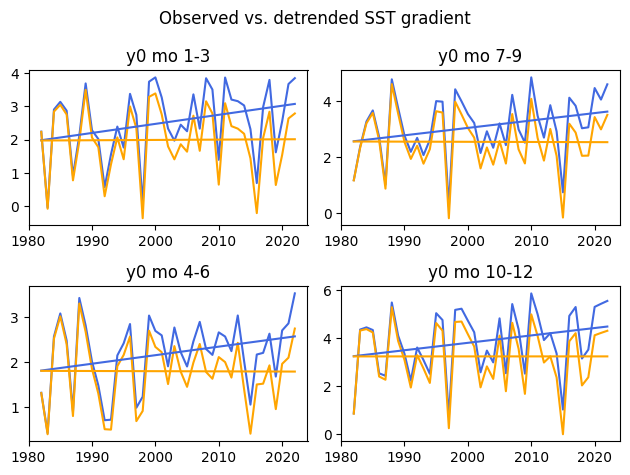

In [40]:
# plot both SST gradients and compare
fig, ax = plt.subplots(2,2)
icol = 0
for i in np.arange(0,2):
    for j in np.arange(0,2):
        tmpindex = np.array(climind82_seasons.iloc[:,icol].index)
        tmpobs = np.array(climind82_seasons.iloc[:,icol])
        tmpDT = np.array(climind82_seasonsDT.iloc[:,icol])
        ax[j,i].plot(tmpindex, tmpobs, label='obs', c='royalblue')
        ax[j,i].plot(tmpindex, tmpDT, label='DT', c='orange')
        ax[j,i].set_title(climind82_seasons.columns[icol])
        # show trendlines
        reg = linregress(tmpindex, tmpobs)
        m = reg.slope
        b = reg.intercept
        regpredict = m*tmpindex + b
        reg2 = linregress(tmpindex, tmpDT)
        m2 = reg2.slope
        b2 = reg2.intercept
        reg2predict = m2*tmpindex + b2
        print('slopes of '+climind83_seasons.columns[icol]+'\t'+'m1: {:.2}\tm2: {:.2}'.format(m, m2))
        ax[j,i].plot(tmpindex, regpredict, label='pos. lin. trend', c='royalblue')
        ax[j,i].plot(tmpindex, reg2predict, label='normalized trend', c='orange')
        icol+=1
fig.suptitle('Observed vs. detrended SST gradient')
fig.tight_layout()

In [41]:
# split the data into the inputs

ant_rolls = int((ant_years+1)*12/ant_season)

# storage; rolling average SSTs
sst_avg_roll = np.zeros((time_length+1, ant_rolls)) # years, rolling periods
labels = [] # labels for each col

icol = 0 # column index
# go through EACH ROLLING PERIOD
for prev in year_rolls:
    years = np.arange(firstyear+prev-1, finalyear+prev+1, 1)
    print(climindname+' index from '+str(years[0])+'-'+str(years[-1]))
    for index in np.arange(len(firstmonth)):
        # grab season from df within correct years
        thisseason = 'y0'+' mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] )
        climavg = climind82_seasonsDT.loc[years[0]:years[-1],thisseason]
        # create string description
        label = 'y'+str(prev)+' mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) 
        labels.append(label)
        print(label)
        # put this rolling period in the overall storage
        sst_avg_roll[:,icol] = climavg
        icol+=1
# put into dataframe
climind83_seasonsDT = pd.DataFrame(sst_avg_roll, index=None, columns=labels)
print(np.shape(climind83_seasonsDT))

ENSO index from 1982-2021
y-1 mo 1-3
y-1 mo 4-6
y-1 mo 7-9
y-1 mo 10-12
ENSO index from 1983-2022
y0 mo 1-3
y0 mo 4-6
y0 mo 7-9
y0 mo 10-12
(40, 8)


In [42]:
# save data
climind82_seasonsDT.to_csv('sstgrad_seasonfull_' +climindfilename+'_82_y.txt')
print('exported sstgrad_seasonfull_' +climindfilename+'_82_y.txt')
climind83_seasonsDT.to_csv('sstgrad_seasons_' +climindfilename+'_82_y.txt')
print('exported sstgrad_seasons_' +climindfilename+'_82_y.txt')

# print last time the data was updated
from datetime import datetime

# datetime object containing current date and time
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print("Data last updated for",climindname,"=", dt_string)

exported sstgrad_seasonfull_DeTrend_patch125-155_nino3-34_82_y.txt
exported sstgrad_seasons_DeTrend_patch125-155_nino3-34_82_y.txt
Data last updated for patch125-155_nino3-34 = 09/01/2025 14:45:32


slopes of y-1 mo 1-3	m1: 0.024	m2: -0.002
slopes of y-1 mo 4-6	m1: 0.015	m2: -0.0041
slopes of y-1 mo 7-9	m1: 0.023	m2: -0.0043
slopes of y-1 mo 10-12	m1: 0.027	m2: -0.0041
slopes of y0 mo 1-3	m1: 0.028	m2: 0.0019
slopes of y0 mo 4-6	m1: 0.017	m2: -0.0023
slopes of y0 mo 7-9	m1: 0.021	m2: -0.0059
slopes of y0 mo 10-12	m1: 0.022	m2: -0.0092


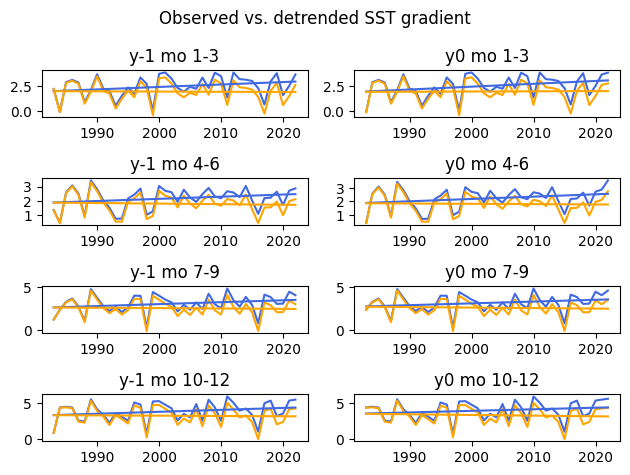

In [43]:
# plot both SST gradients and compare
fig, ax = plt.subplots(4,2)
icol = 0
for i in np.arange(0,2):
    for j in np.arange(0,4):
        tmpobs = np.array(climind83_seasons.iloc[:,icol])
        tmpDT = np.array(climind83_seasonsDT.iloc[:,icol])
        ax[j,i].plot(years, tmpobs, label='obs', c='royalblue')
        ax[j,i].plot(years, tmpDT, label='DT', c='orange')
        ax[j,i].set_title(climind83_seasons.columns[icol])
        # show trendlines
        reg = linregress(years, tmpobs)
        m = reg.slope
        b = reg.intercept
        regpredict = m*years + b
        reg2 = linregress(years, tmpDT)
        m2 = reg2.slope
        b2 = reg2.intercept
        reg2predict = m2*years + b2
        print('slopes of '+climind83_seasons.columns[icol]+'\t'+'m1: {:.2}\tm2: {:.2}'.format(m, m2))
        ax[j,i].plot(years, regpredict, label='pos. lin. trend', c='royalblue')
        ax[j,i].plot(years, reg2predict, label='normalized trend', c='orange')
        icol+=1
fig.suptitle('Observed vs. detrended SST gradient')
fig.tight_layout()

# SST Gradient (1981 to present-1, 1982 to present)

## climind_seasons (1981 to present-1, 1982 to present)

**Swap out the `climindname` variable to the correct one to update**

For predicting concurrent-year variables

Extended SST gradient dataset, for predicting longer timeseries of data of climate datasets

In [44]:
# gradient: (125-155 deg lon) - nino3.4 (190-240 deg)
firstyearclim = firstyear-ant_years-2 # changed the number of years
filename = 'gradient_'+climindname+'.txt'
print(filename)
climind = pd.read_csv(filename, header=None, sep=",", skiprows=[0]).set_index(0)
climind = climind.loc[(firstyearclim):finalyear] # crop
print('cropped data to '+str(firstyearclim)+' to '+str(finalyear))



# get dates associated with beginning of every 3 months
firstdate = str(firstyearclim)+'-01-15'
lastdate = str(finalyear+1)+'-01-15'
ninodate = pd.to_datetime(pd.date_range(start=firstdate, end=lastdate, freq='M'), unit='M')
ninotime = pd.DatetimeIndex(ninodate, freq='1M')
# flatten
climind = climind.to_numpy().flatten()
# create pd dataframe
climind_df = pd.DataFrame(data={'time': ninodate, 'anomaly': climind}).set_index('time')

gradient_patch125-155_nino3-34.txt
cropped data to 1981 to 2022


In [45]:
# a few definitions to help the for-loop

# get years of data to look at
year_rolls = np.arange(-ant_years, 1, 1)

# this is number of seasons (based on user inputs)
firstmonth = np.arange(1, (12*ant_years), ant_season)
finalmonth = np.arange(ant_season, (12*ant_years+ant_season), ant_season)
lastdate = str(finalyear)+'-12-15'

prec2 = xr.open_dataset(directory + primary_string + 'prec.nc')
prec2 = prec2.prec.loc[firstdate:lastdate]
time = prec2.time # xarray datetime format

In [46]:
# create a timeseries of just all the observed SST by season

ant_rolls = int(12/ant_season)
obs_tot = np.zeros((time_length+3, ant_rolls)) # years, rolling periods

# define the seasons and years
firstmonth = np.arange(1, 12, ant_season)
finalmonth = np.arange(ant_season, 12+1, ant_season)
years = np.arange(firstyearclim, finalyear+1)

labels = []
icol=0
for index in np.arange(len(firstmonth)):
    print('ENSO index from '+str(years[0])+'-'+str(years[-1]))
    climavg = annual_seasonAvg(climind_df.anomaly.values, firstmonth[index], finalmonth[index])
    # create string description
    label = 'y0 mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) 
    labels.append(label)
    print(label)
    # put this rolling period in the overall storage
    obs_tot[:,icol] = climavg
    icol+=1

# put into dataframe
climind82_seasons = pd.DataFrame(obs_tot, index=years, columns=labels)

ENSO index from 1981-2022
y0 mo 1-3
ENSO index from 1981-2022
y0 mo 4-6
ENSO index from 1981-2022
y0 mo 7-9
ENSO index from 1981-2022
y0 mo 10-12


In [47]:
# split the data into prior and concurrent seasons
ant_rolls = int((ant_years+1)*12/ant_season)

# storage; rolling average SSTs
sst_avg_roll = np.zeros((time_length+2, ant_rolls)) # years, rolling periods
labels = [] # labels for each col

icol = 0 # column index
# go through EACH ROLLING PERIOD
for prev in year_rolls:
    years = np.arange(firstyear+prev-2, finalyear+prev+1, 1)
    print('ENSO index from '+str(years[0])+'-'+str(years[-1]))
    for index in np.arange(len(firstmonth)):
        climavg = annual_seasonAvg(climind_df.anomaly.values, firstmonth[index], finalmonth[index])
        # create string description
        label = 'y'+str(prev)+' mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) 
        labels.append(label)
        print(label)
        # put this rolling period in the overall storage
        sst_avg_roll[:,icol] = climavg
        icol+=1
# put into dataframe
climind83_seasons = pd.DataFrame(sst_avg_roll, index=None, columns=labels)

ENSO index from 1981-2021
y-1 mo 1-3
y-1 mo 4-6
y-1 mo 7-9
y-1 mo 10-12
ENSO index from 1982-2022
y0 mo 1-3
y0 mo 4-6
y0 mo 7-9
y0 mo 10-12


In [48]:
# save data
climind82_seasons.to_csv('sstgrad_seasonfull_' +climindname+'_81_y.txt')
print('exported sstgrad_seasonfull_' +climindname+'_81_y.txt')
climind83_seasons.to_csv('sstgrad_seasons_' +climindname +'_81_y.txt')
print('exported sstgrad_seasons_' +climindname+'_81_y.txt')

# print last time the data was updated
from datetime import datetime
# datetime object containing current date and time
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print("Data last updated for",climindname,"=", dt_string)

exported sstgrad_seasonfull_patch125-155_nino3-34_81_y.txt
exported sstgrad_seasons_patch125-155_nino3-34_81_y.txt
Data last updated for patch125-155_nino3-34 = 09/01/2025 14:45:32


## DETRENDED climind_seasons (1981 to present-1, 1982 to present)

**Swap out the `climindname` variable to the correct one to update**

1. The entire 1982-2021 trendline is detrended by 3-month season by removing the slope from each season's data (from the previous part)
2. The data is split into prior-season and current-season variables by either selecting years 1982-2020 or 1983-2021.

In [49]:
# gradient: (125-155 deg lon) - nino3.4 (190-240 deg)
climindfilename = 'DeTrend_'+climindname
filename = 'gradient_'+climindname+'.txt'
print(filename)
firstyearclim = firstyear-ant_years-2
climind = pd.read_csv(filename, header=None, sep=",", skiprows=[0]).set_index(0)
climind = climind.loc[(firstyearclim):finalyear] # crop
print('cropped data to '+str(firstyearclim)+' to '+str(finalyear))

# get dates associated with beginning of every 3 months
firstdate = str(firstyearclim)+'-01-15'
lastdate = str(finalyear+1)+'-01-15'
ninodate = pd.to_datetime(pd.date_range(start=firstdate, end=lastdate, freq='M'), unit='M')
ninotime = pd.DatetimeIndex(ninodate, freq='1M')
# flatten
climind = climind.to_numpy().flatten()
# create pd dataframe
climind_df = pd.DataFrame(data={'time': ninodate, 'anomaly': climind}).set_index('time')

gradient_patch125-155_nino3-34.txt
cropped data to 1981 to 2022


In [50]:
# a few definitions to help the for-loop

# get years of data to look at
year_rolls = np.arange(-ant_years, 1, 1)

# this is number of seasons (based on user inputs)
firstmonth = np.arange(1, 12, ant_season)
finalmonth = np.arange(ant_season, 12+1, ant_season)
lastdate = str(finalyear)+'-12-15'

prec2 = xr.open_dataset(directory + primary_string + 'prec.nc')
prec2 = prec2.prec.loc[firstdate:lastdate]
time = prec2.time # xarray datetime format

In [51]:
# DETREND the entire timeseries by season (1982-2021)

ant_rolls = int(12/ant_season)
detrend_tot = np.zeros((time_length+3, ant_rolls)) # years, rolling periods

# define the seasons
firstmonth = np.arange(1, 12, ant_season)
finalmonth = np.arange(ant_season, 12+1, ant_season)
lastdate = str(finalyear)+'-12-15'
prec2 = xr.open_dataset(directory + primary_string + 'prec.nc')
prec2 = prec2.prec.loc[firstdate:lastdate]
years = np.arange(firstyearclim, finalyear+1)

labels = []
icol=0
for index in np.arange(len(firstmonth)):
    print('ENSO index from '+str(years[0])+'-'+str(years[-1]))
    climavg = annual_seasonAvgDT(climind_df.anomaly.values, firstmonth[index], finalmonth[index])
    # create string description
    label = 'y0 mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) 
    labels.append(label)
    print(label)
    # put this rolling period in the overall storage
    detrend_tot[:,icol] = climavg
    icol+=1

# put into dataframe
climind82_seasonsDT = pd.DataFrame(detrend_tot, index=years, columns=labels)
print(np.shape(climind82_seasonsDT))

ENSO index from 1981-2022
y0 mo 1-3
ENSO index from 1981-2022
y0 mo 4-6
ENSO index from 1981-2022
y0 mo 7-9
ENSO index from 1981-2022
y0 mo 10-12
(42, 4)


slopes of y-1 mo 1-3	m1: 0.024	m2: 0.00091
slopes of y-1 mo 4-6	m1: 0.017	m2: -0.00038
slopes of y-1 mo 7-9	m1: 0.023	m2: -0.00056
slopes of y-1 mo 10-12	m1: 0.028	m2: 1.6e-05


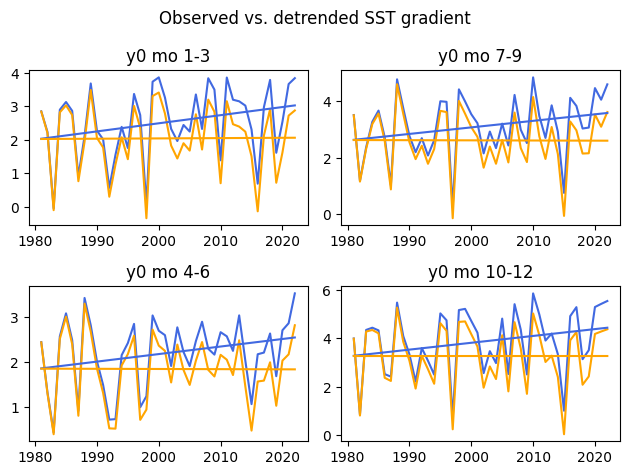

In [52]:
# plot both SST gradients and compare
fig, ax = plt.subplots(2,2)
icol = 0
for i in np.arange(0,2):
    for j in np.arange(0,2):
        tmpindex = np.array(climind82_seasons.iloc[:,icol].index)
        tmpobs = np.array(climind82_seasons.iloc[:,icol])
        tmpDT = np.array(climind82_seasonsDT.iloc[:,icol])
        ax[j,i].plot(tmpindex, tmpobs, label='obs', c='royalblue')
        ax[j,i].plot(tmpindex, tmpDT, label='DT', c='orange')
        ax[j,i].set_title(climind82_seasons.columns[icol])
        # show trendlines
        reg = linregress(tmpindex, tmpobs)
        m = reg.slope
        b = reg.intercept
        regpredict = m*tmpindex + b
        reg2 = linregress(tmpindex, tmpDT)
        m2 = reg2.slope
        b2 = reg2.intercept
        reg2predict = m2*tmpindex + b2
        print('slopes of '+climind83_seasons.columns[icol]+'\t'+'m1: {:.2}\tm2: {:.2}'.format(m, m2))
        ax[j,i].plot(tmpindex, regpredict, label='pos. lin. trend', c='royalblue')
        ax[j,i].plot(tmpindex, reg2predict, label='normalized trend', c='orange')
        icol+=1
fig.suptitle('Observed vs. detrended SST gradient')
fig.tight_layout()

In [53]:
# split the data into the inputs

ant_rolls = int((ant_years+1)*12/ant_season)

# storage; rolling average SSTs
sst_avg_roll = np.zeros((time_length+2, ant_rolls)) # years, rolling periods
labels = [] # labels for each col

icol = 0 # column index
# go through EACH ROLLING PERIOD
for prev in year_rolls:
    years = np.arange(firstyear+prev-2, finalyear+prev+1, 1)
    print('ENSO index from '+str(years[0])+'-'+str(years[-1]))
    for index in np.arange(len(firstmonth)):
        # grab season from df within correct years
        thisseason = 'y0'+' mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] )
        climavg = climind82_seasonsDT.loc[years[0]:years[-1],thisseason]
        # create string description
        label = 'y'+str(prev)+' mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) 
        labels.append(label)
        print(label)
        # put this rolling period in the overall storage
        sst_avg_roll[:,icol] = climavg
        icol+=1
# put into dataframe
climind83_seasonsDT = pd.DataFrame(sst_avg_roll, index=None, columns=labels)
print(np.shape(climind83_seasonsDT))

ENSO index from 1981-2021
y-1 mo 1-3
y-1 mo 4-6
y-1 mo 7-9
y-1 mo 10-12
ENSO index from 1982-2022
y0 mo 1-3
y0 mo 4-6
y0 mo 7-9
y0 mo 10-12
(41, 8)


In [54]:
# save data
climind82_seasonsDT.to_csv('sstgrad_seasonfull_' +climindfilename+'_81_y.txt')
print('exported sstgrad_seasonfull_' +climindfilename+'_81_y.txt')
climind83_seasonsDT.to_csv('sstgrad_seasons_' +climindfilename+'_81_y.txt')
print('exported sstgrad_seasons_' +climindfilename+'_81_y.txt')

# print last time the data was updated
from datetime import datetime

# datetime object containing current date and time
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print("Data last updated for",climindname,"=", dt_string)

exported sstgrad_seasonfull_DeTrend_patch125-155_nino3-34_81_y.txt
exported sstgrad_seasons_DeTrend_patch125-155_nino3-34_81_y.txt
Data last updated for patch125-155_nino3-34 = 09/01/2025 14:45:33


slopes of y-1 mo 1-3	m1: 0.021	m2: -0.0021
slopes of y-1 mo 4-6	m1: 0.013	m2: -0.004
slopes of y-1 mo 7-9	m1: 0.019	m2: -0.0043
slopes of y-1 mo 10-12	m1: 0.024	m2: -0.004
slopes of y0 mo 1-3	m1: 0.027	m2: 0.0039
slopes of y0 mo 4-6	m1: 0.019	m2: 0.0018
slopes of y0 mo 7-9	m1: 0.026	m2: 0.0027
slopes of y0 mo 10-12	m1: 0.031	m2: 0.0026


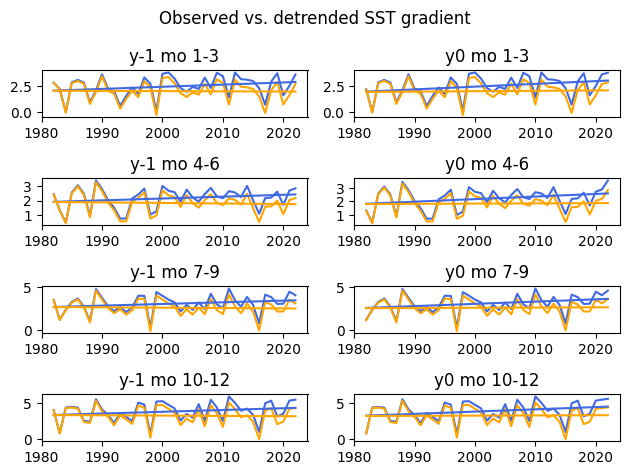

In [55]:
# plot both SST gradients and compare
fig, ax = plt.subplots(4,2)
icol = 0
for i in np.arange(0,2):
    for j in np.arange(0,4):
        tmpobs = np.array(climind83_seasons.iloc[:,icol])
        tmpDT = np.array(climind83_seasonsDT.iloc[:,icol])
        ax[j,i].plot(years, tmpobs, label='obs', c='royalblue')
        ax[j,i].plot(years, tmpDT, label='DT', c='orange')
        ax[j,i].set_title(climind83_seasons.columns[icol])
        # show trendlines
        reg = linregress(years, tmpobs)
        m = reg.slope
        b = reg.intercept
        regpredict = m*years + b
        reg2 = linregress(years, tmpDT)
        m2 = reg2.slope
        b2 = reg2.intercept
        reg2predict = m2*years + b2
        print('slopes of '+climind83_seasons.columns[icol]+'\t'+'m1: {:.2}\tm2: {:.2}'.format(m, m2))
        ax[j,i].plot(years, regpredict, label='pos. lin. trend', c='royalblue')
        ax[j,i].plot(years, reg2predict, label='normalized trend', c='orange')
        icol+=1
fig.suptitle('Observed vs. detrended SST gradient')
fig.tight_layout()

In [56]:
# datetime object containing current date and time
from datetime import datetime
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print('SST gradient exported: '+climindname)
print("Last export =", dt_string)

SST gradient exported: patch125-155_nino3-34
Last export = 09/01/2025 14:45:33


# SST Gradient (average of prior-season and current-season)

(7/22/2024)

Average of prior-season and current-season gSST. Import all the previously-made gSST dataframes, rearrange, and export as its own file so it can be imported into the model for training.

In [57]:
# import
climindfilename = 'DeTrend_'+climindname
print('reading DeTrended '+climindname)
climindseasons82Obs = pd.read_csv('sstgrad_seasons_' +climindname+'_81_y.txt').set_index('Unnamed: 0')
climindseasons82DT = pd.read_csv('sstgrad_seasons_' +climindfilename+'_81_y.txt').set_index('Unnamed: 0')
climindseasons83Obs = pd.read_csv('sstgrad_seasons_' +climindname+'_82_y.txt').set_index('Unnamed: 0')
climindseasons83DT = pd.read_csv('sstgrad_seasons_' +climindfilename+'_82_y.txt').set_index('Unnamed: 0')

reading DeTrended patch125-155_nino3-34


In [58]:
# (7/19/2024) Get average of prior-season and concurrent-season
# replace the prior-season gSST with gSST_avg

climindseasons82Obs_avg = []
climindseasons82DT_avg = []
climindseasons83Obs_avg = []
climindseasons83DT_avg = []
ncols = len(climindseasons83Obs.columns)

for icol in np.arange(1, ncols):
    tmpcurrent2 = climindseasons82Obs.iloc[:,icol]
    tmpprior2 = climindseasons82Obs.iloc[:,icol-1]
    tmpavg2 = (tmpcurrent2 + tmpprior2)/2

    tmpcurrentDT2 = climindseasons82DT.iloc[:,icol]
    tmppriorDT2 = climindseasons82DT.iloc[:,icol-1]
    tmpavgDT2 = (tmpcurrentDT2 + tmppriorDT2)/2
    
    tmpcurrent3 = climindseasons83Obs.iloc[:,icol]
    tmpprior3 = climindseasons83Obs.iloc[:,icol-1]
    tmpavg3 = (tmpcurrent3 + tmpprior3)/2

    tmpcurrentDT3 = climindseasons83DT.iloc[:,icol]
    tmppriorDT3 = climindseasons83DT.iloc[:,icol-1]
    tmpavgDT3 = (tmpcurrentDT3 + tmppriorDT3)/2
    # add to a list
    climindseasons82Obs_avg.append(tmpavg2.to_list())
    climindseasons82DT_avg.append(tmpavgDT2.to_list())
    climindseasons83Obs_avg.append(tmpavg3.to_list())
    climindseasons83DT_avg.append(tmpavgDT3.to_list())

# column names now with the averages of the seasons
avglabels = ['y-1 mo 1-6', 'y-1 mo 4-9', 'y-1 mo 7-12',
             'y-1 mo 10-3', 'y0 mo 1-6', 'y0 mo 4-9', 
             'y0 mo 7-12']

climindseasons82Obs_avgdf = pd.DataFrame(np.array(climindseasons82Obs_avg).transpose(), index=climindseasons82Obs.index, columns=avglabels)
climindseasons82DT_avgdf = pd.DataFrame(np.array(climindseasons82DT_avg).transpose(), index=climindseasons82DT.index, columns=avglabels)
climindseasons83Obs_avgdf = pd.DataFrame(np.array(climindseasons83Obs_avg).transpose(), index=climindseasons83Obs.index, columns=avglabels)
climindseasons83DT_avgdf = pd.DataFrame(np.array(climindseasons83DT_avg).transpose(), index=climindseasons83DT.index, columns=avglabels)

In [59]:
# export
# save data
climindseasons82Obs_avgdf.to_csv('sstgrad_seasons_' +climindname+'_81_y_avgcurr-prior.txt')
print('exported sstgrad_seasonfull_' +climindfilename+'_81_y_avgcurr-prior.txt')
climindseasons82DT_avgdf.to_csv('sstgrad_seasons_' +climindfilename+'_81_y_avgcurr-prior.txt')
print('exported sstgrad_seasons_' +climindfilename+'_81_y_avgcurr-prior.txt')
climindseasons83Obs_avgdf.to_csv('sstgrad_seasons_' +climindname+'_82_y_avgcurr-prior.txt')
print('exported sstgrad_seasonfull_' +climindfilename+'_82_y_avgcurr-prior.txt')
climindseasons83DT_avgdf.to_csv('sstgrad_seasons_' +climindfilename+'_82_y_avgcurr-prior.txt')
print('exported sstgrad_seasons_' +climindfilename+'_82_y_avgcurr-prior.txt')

# print last time the data was updated
from datetime import datetime

# datetime object containing current date and time
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print("Data last updated for",climindname,"=", dt_string)

exported sstgrad_seasonfull_DeTrend_patch125-155_nino3-34_81_y_avgcurr-prior.txt
exported sstgrad_seasons_DeTrend_patch125-155_nino3-34_81_y_avgcurr-prior.txt
exported sstgrad_seasonfull_DeTrend_patch125-155_nino3-34_82_y_avgcurr-prior.txt
exported sstgrad_seasons_DeTrend_patch125-155_nino3-34_82_y_avgcurr-prior.txt
Data last updated for patch125-155_nino3-34 = 09/01/2025 14:45:33
